In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')



In [2]:
df = pd.read_csv('../data/cleaned_accident_data.csv')
print("Shape:", df.shape)
df.head()

Shape: (1000, 26)


,accident_id,date,week_day,state,severity,weather,location,time,light_condition,vehicle_type,...,casualty_age,casualty_sex,social_class,casualty_type,pedestrian_or_passenger,year,month,month_name,hour,time_of_day
0,AID0001,2022-11-20,T,WB,Minor,Storm,Loc91,1958,Daylight,Car,...,33,M,Upper,Pedestrian,Pedestrian,2022,11,November,19,Evening
1,AID0002,2023-12-09,T,TR,Severe,Fog,Loc184,2245,Daylight,Car,...,9,M,Middle,Pedestrian,Pedestrian,2023,12,December,22,Night
2,AID0003,2022-11-12,W,HP,Moderate,Fog,Loc77,250,Twilight,Car,...,45,F,Working,Car Passenger,Pedestrian,2022,11,November,2,Night
3,AID0004,2023-02-13,T,CG,Severe,Clear,Loc78,545,Night,Motorcycle,...,59,M,Working,Motorcyclist,Pedestrian,2023,2,February,5,Night
4,AID0005,2022-11-25,S,TR,Moderate,Storm,Loc57,2146,Twilight,Car,...,30,F,Working,Cyclist,Pedestrian,2022,11,November,21,Night


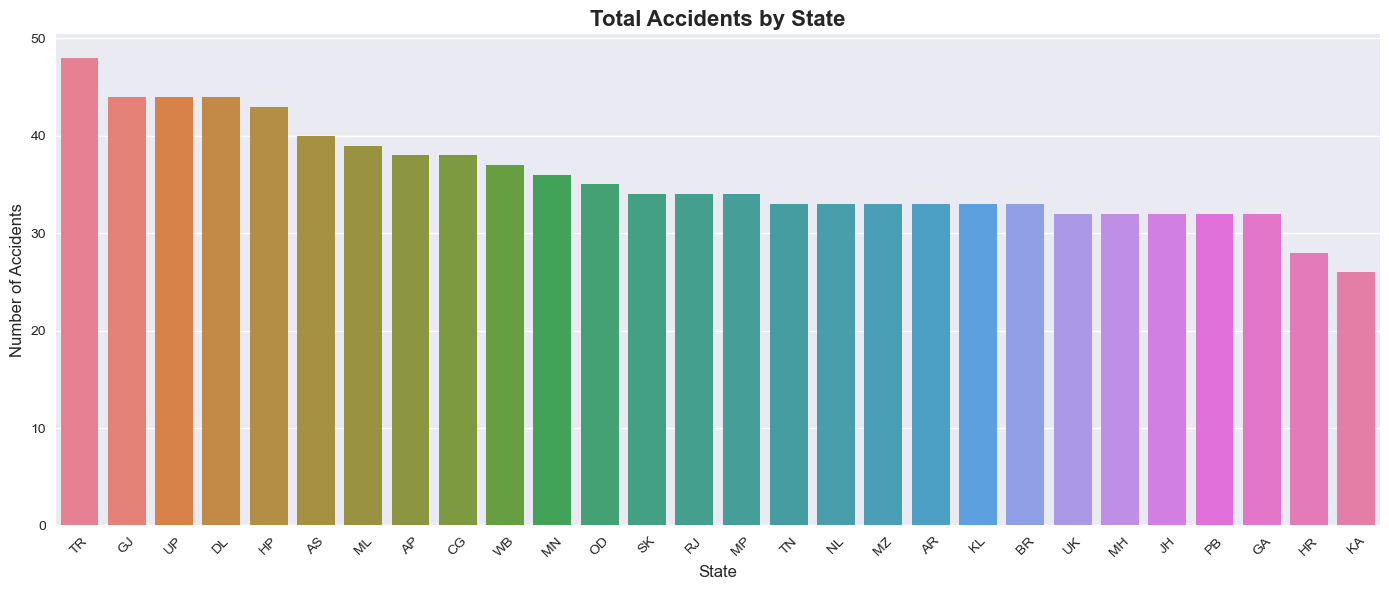

Top 5 states with most accidents:
state
TR    48
GJ    44
UP    44
DL    44
HP    43
Name: count, dtype: int64


In [3]:
#Accidents by state 

plt.figure(figsize=(14, 6))
state_counts = df['state'].value_counts()
sns.barplot(x=state_counts.index, y=state_counts.values, palette='husl')
plt.title('Total Accidents by State', fontsize=16, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/accidents_by_state.png', dpi=150)
plt.show()
print("Top 5 states with most accidents:")
print(state_counts.head())

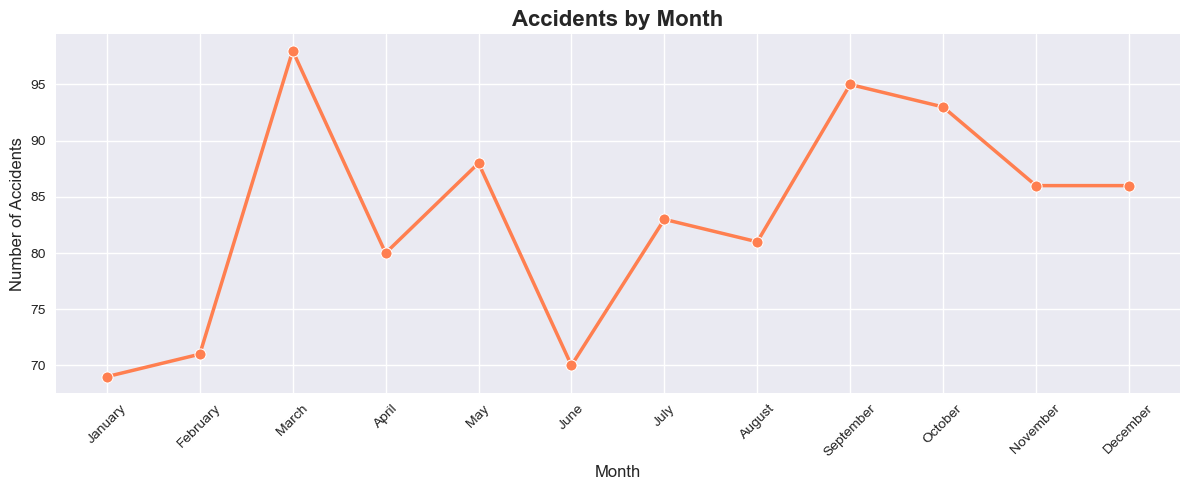

In [4]:
#Accidents By month 
plt.figure(figsize = (12,5))
month_counts = df.groupby(['month','month_name']).size().reset_index(name = 'count')
month_counts = month_counts.sort_values('month')
sns.lineplot(data=month_counts, x='month_name', y='count', 
             marker='o', linewidth=2.5, markersize=8, color='coral')
plt.title('Accidents by Month', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/accidents_by_month.png', dpi=150)
plt.show()

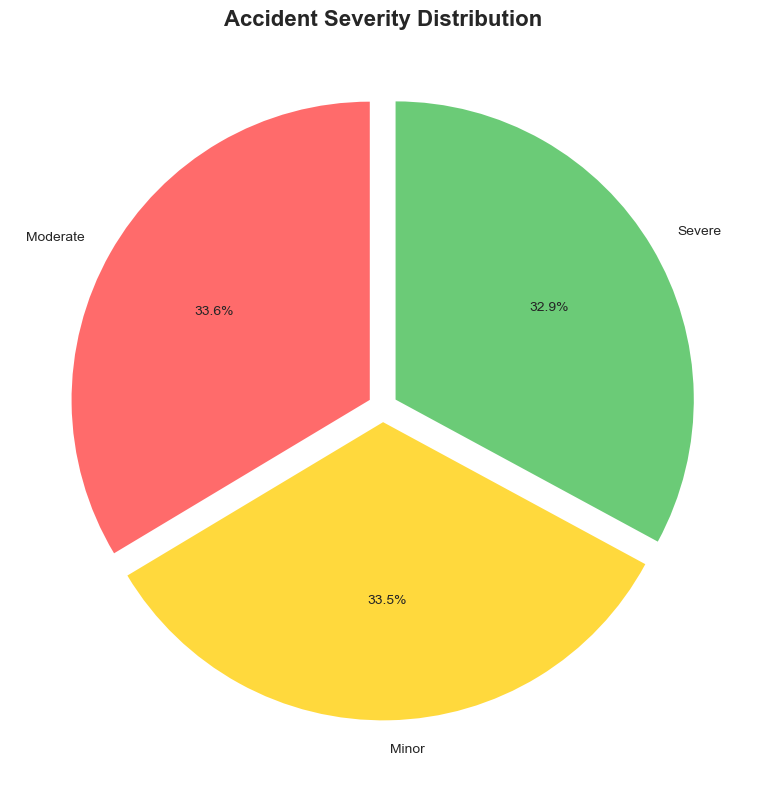

severity
Moderate    336
Minor       335
Severe      329
Name: count, dtype: int64


In [5]:
#Severity Distribution
plt.figure(figsize=(8, 8))
severity_counts = df['severity'].value_counts()
colors = ['#FF6B6B', '#FFD93D', '#6BCB77']
plt.pie(severity_counts.values, 
        labels=severity_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        explode=[0.05] * len(severity_counts))
plt.title('Accident Severity Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/severity_distribution.png', dpi=150)
plt.show()
print(severity_counts)

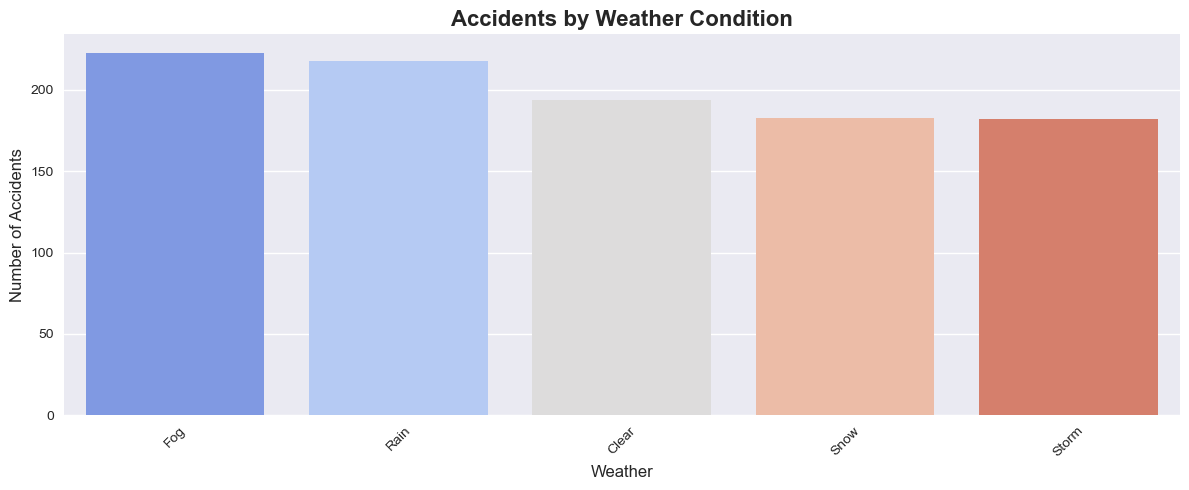

weather
Fog      223
Rain     218
Clear    194
Snow     183
Storm    182
Name: count, dtype: int64


In [6]:
#weather v/s Accidents 
plt.figure(figsize=(12, 5))
weather_counts = df['weather'].value_counts()
sns.barplot(x=weather_counts.index, y=weather_counts.values, palette='coolwarm')
plt.title('Accidents by Weather Condition', fontsize=16, fontweight='bold')
plt.xlabel('Weather', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/accidents_by_weather.png', dpi=150)
plt.show()
print(weather_counts)

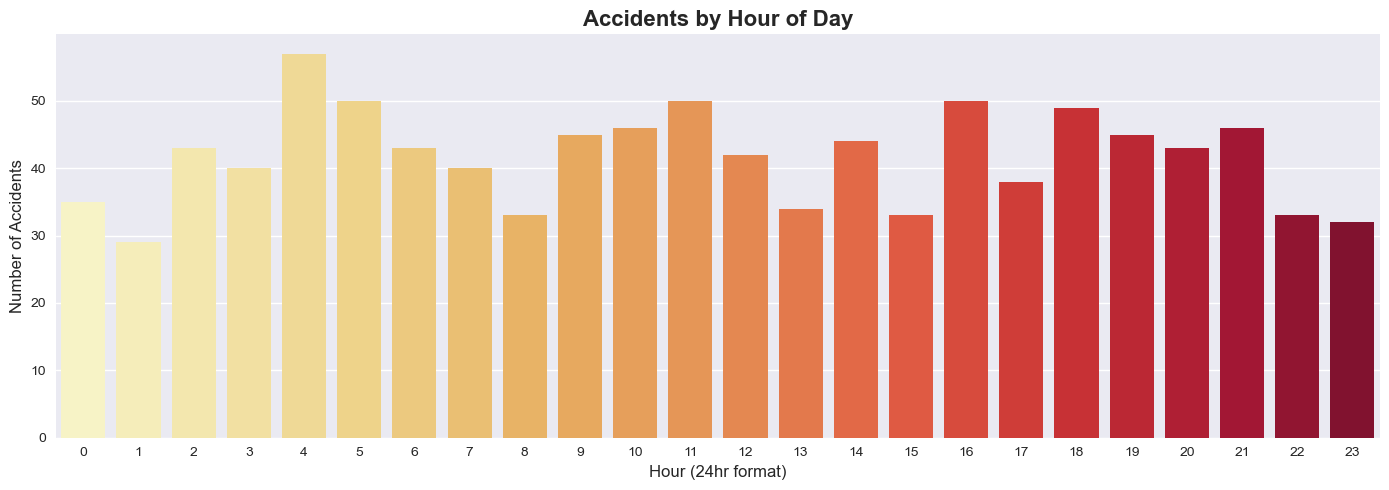

Most dangerous hour: 4


In [7]:
#hours of day Heatmap 
plt.figure(figsize=(14, 5))
hour_counts = df['hour'].value_counts().sort_index()
sns.barplot(x=hour_counts.index, y=hour_counts.values, palette='YlOrRd')
plt.title('Accidents by Hour of Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour (24hr format)', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.tight_layout()
plt.savefig('../data/accidents_by_hour.png', dpi=150)
plt.show()
print("Most dangerous hour:", hour_counts.idxmax())

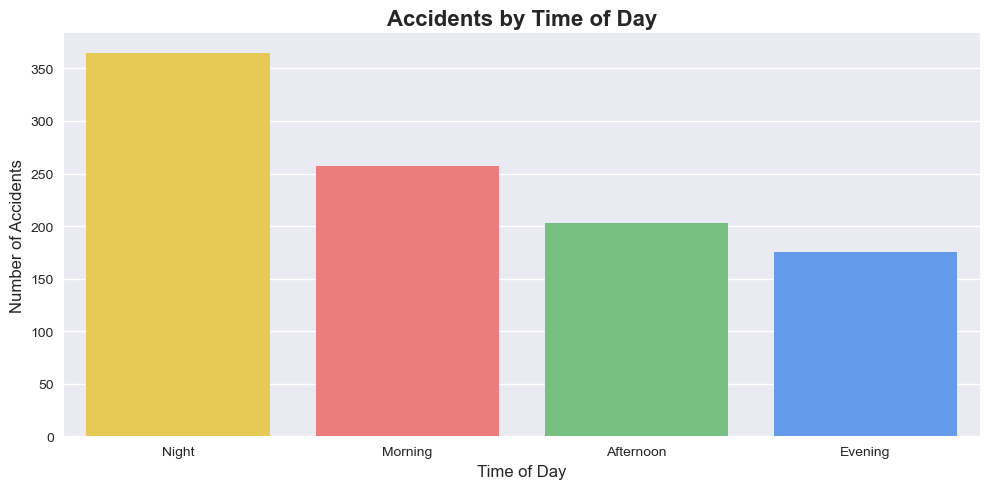

In [8]:
#time of Day Analysis
plt.figure(figsize=(10, 5))
tod_counts = df['time_of_day'].value_counts()
colors = ['#FFD93D', '#FF6B6B', '#6BCB77', '#4D96FF']
sns.barplot(x=tod_counts.index, y=tod_counts.values, palette=colors)
plt.title('Accidents by Time of Day', fontsize=16, fontweight='bold')
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.tight_layout()
plt.savefig('../data/accidents_by_timeofday.png', dpi=150)
plt.show()

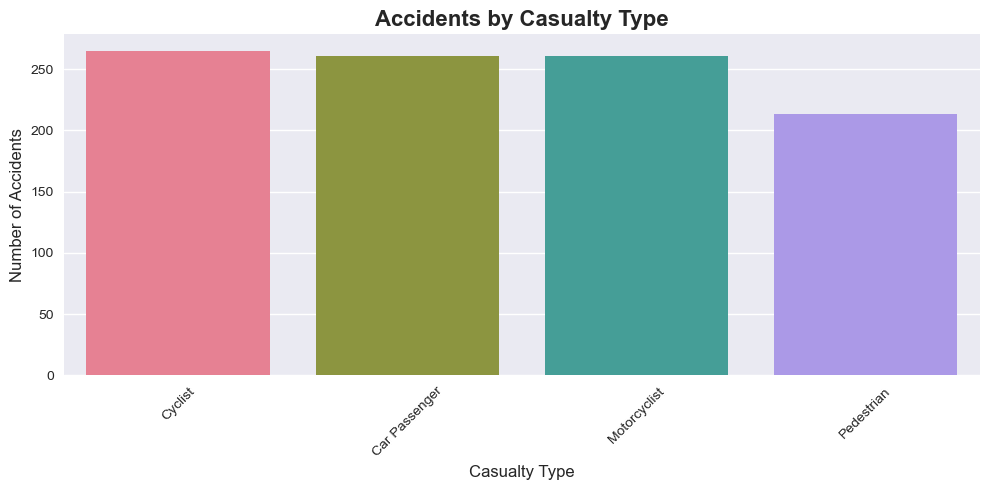

casualty_type
Cyclist          265
Car Passenger    261
Motorcyclist     261
Pedestrian       213
Name: count, dtype: int64


In [15]:

# Cell 9 - Casualty Type vs Accidents
plt.figure(figsize=(10, 5))
casualty_counts = df['casualty_type'].value_counts()
sns.barplot(x=casualty_counts.index, y=casualty_counts.values, palette='husl')
plt.title('Accidents by Casualty Type', fontsize=16, fontweight='bold')
plt.xlabel('Casualty Type', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/accidents_by_casualty.png', dpi=150)
plt.show()
print(casualty_counts)

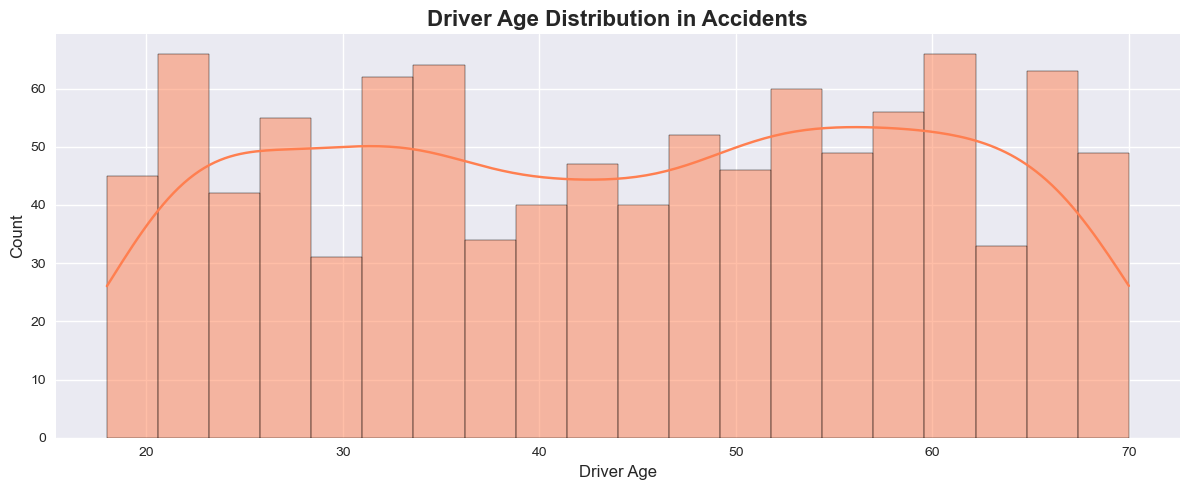

Average driver age: 44.2
Youngest driver: 18
Oldest driver: 70


In [10]:
#Driver Age Distribution 
plt.figure(figsize=(12, 5))
sns.histplot(df['driver_age'], bins=20, kde=True, color='coral')
plt.title('Driver Age Distribution in Accidents', fontsize=16, fontweight='bold')
plt.xlabel('Driver Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig('../data/driver_age_distribution.png', dpi=150)
plt.show()
print("Average driver age:", round(df['driver_age'].mean(), 1))
print("Youngest driver:", df['driver_age'].min())
print("Oldest driver:", df['driver_age'].max())

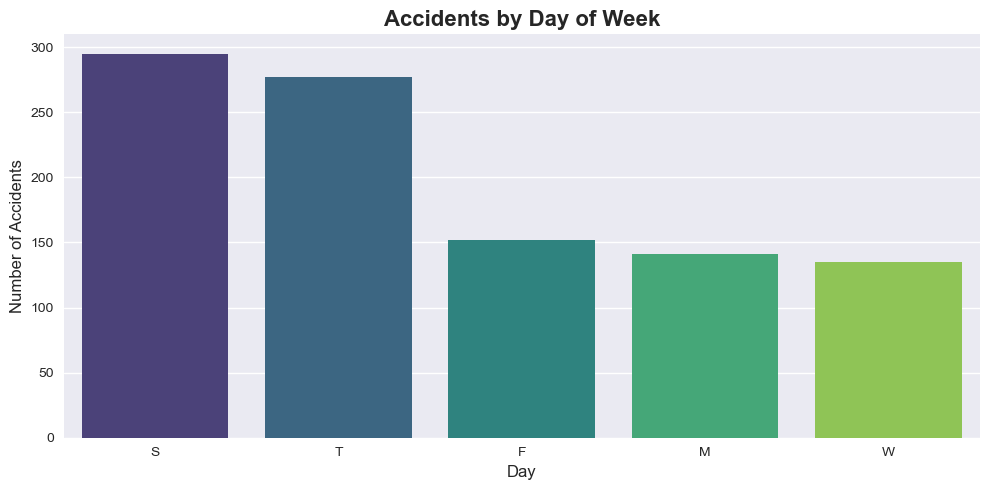

In [12]:
#Day of Week Analysis 
plt.figure(figsize=(10, 5))
day_counts = df['week_day'].value_counts()
sns.barplot(x=day_counts.index, y=day_counts.values, palette='viridis')
plt.title('Accidents by Day of Week', fontsize=16, fontweight='bold')
plt.xlabel('Day', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.tight_layout()
plt.savefig('../data/accidents_by_day.png', dpi=150)
plt.show()

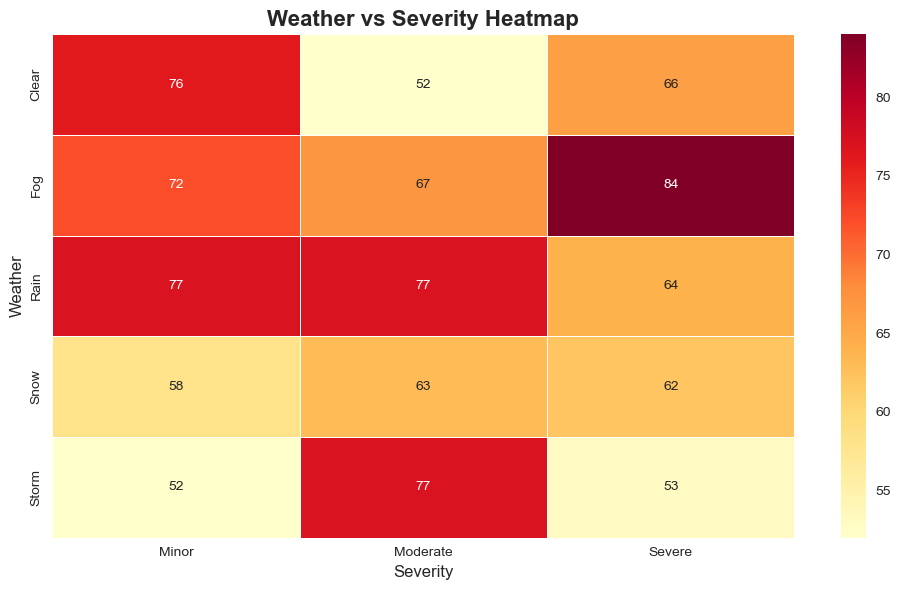

In [13]:
#Severity V/s weather 
plt.figure(figsize=(10, 6))
pivot = pd.crosstab(df['weather'], df['severity'])
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Weather vs Severity Heatmap', fontsize=16, fontweight='bold')
plt.xlabel('Severity', fontsize=12)
plt.ylabel('Weather', fontsize=12)
plt.tight_layout()
plt.savefig('../data/weather_severity_heatmap.png', dpi=150)
plt.show()

In [14]:
#key Insight Summary 
print("=" * 50)
print("       KEY INSIGHTS FROM EDA")
print("=" * 50)
print(f"Total Accidents: {len(df)}")
print(f"States Covered: {df['state'].nunique()}")
print(f"Most Accident Prone State: {df['state'].value_counts().idxmax()}")
print(f"Most Dangerous Weather: {df['weather'].value_counts().idxmax()}")
print(f"Most Dangerous Hour: {df['hour'].value_counts().idxmax()}:00")
print(f"Most Common Severity: {df['severity'].value_counts().idxmax()}")
print(f"Most Common Vehicle: {df['vehicle_type'].value_counts().idxmax()}")
print(f"Average Driver Age: {round(df['driver_age'].mean(), 1)}")
print("=" * 50)

       KEY INSIGHTS FROM EDA
Total Accidents: 1000
States Covered: 28
Most Accident Prone State: TR
Most Dangerous Weather: Fog
Most Dangerous Hour: 4:00
Most Common Severity: Moderate
Most Common Vehicle: Motorcycle
Average Driver Age: 44.2
